# Week 3: Clustering Models & Customer Segmentation

## 1. Data Ingestion & Structural Examination
We begin by loading the Mall Customer Segmentation Dataset from the local `data/` repository directory. We examine its dimensionality, data types, and check for missing values to ensure the integrity of the data pipeline before applying distance-based clustering algorithms.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vjchoudhary7/customer-segmentation-tutorial-in-python",
    "Mall_Customers.csv"
)

print("--- DATASET STRUCTURE ---")
print(f"Shape: {df.shape}")
print("\n--- DATA TYPES ---")
print(df.dtypes)
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

100%|██████████| 3.89k/3.89k [00:00<00:00, 6.13MB/s]

--- DATASET STRUCTURE ---
Shape: (200, 5)

--- DATA TYPES ---
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

--- MISSING VALUES ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- SUMMARY STATISTICS ---
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000       

## 2. Feature Selection & Standardization
Clustering algorithms (K-Means, Hierarchical, DBSCAN) rely on spatial distance metrics (e.g., Euclidean distance). Therefore, features with larger magnitudes can disproportionately influence the algorithm. We isolate the continuous numerical features—Age, Annual Income, and Spending Score—and normalize them using `StandardScaler` to ensure a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling complete. Scaled array shape:", X_scaled.shape)

Feature scaling complete. Scaled array shape: (200, 3)


## 3. K-Means Clustering & Centroid Optimization
We iterate K-Means across a range of $k$ values (1-10) to compute the within-cluster sum of squares (inertia). The Elbow Method allows us to visually identify the optimal number of clusters. Once $k$ is identified, we fit the final model, evaluate its cohesion and separation via the Silhouette Score, and visualize the segments.

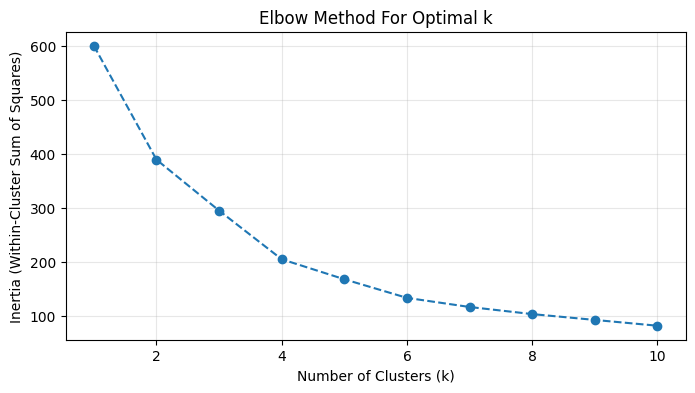

Final K-Means Silhouette Score (k=5): 0.4166


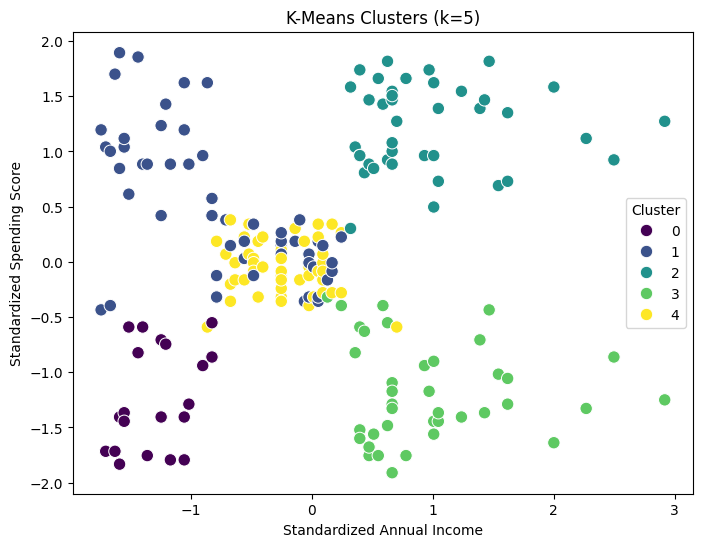

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True, alpha=0.3)
plt.show()

# Based on typical Mall Customer distributions, the elbow occurs at k=5
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Final K-Means Silhouette Score (k={optimal_k}): {sil_score:.4f}")

plt.figure(figsize=(8, 6))
# Plotting Income (index 1) vs Spending Score (index 2)
sns.scatterplot(x=X_scaled[:, 1], y=X_scaled[:, 2], hue=kmeans_labels, palette='viridis', s=80)
plt.title(f'K-Means Clusters (k={optimal_k})')
plt.xlabel('Standardized Annual Income')
plt.ylabel('Standardized Spending Score')
plt.legend(title='Cluster')
plt.show()

## 4. Agglomerative Hierarchical Clustering
To validate the cluster structure identified by K-Means, we construct a dendrogram using Ward's minimum variance method. This bottom-up approach visualizes the hierarchical relationship between data points, allowing us to truncate the tree at the optimal distance to form our final agglomerative clusters.

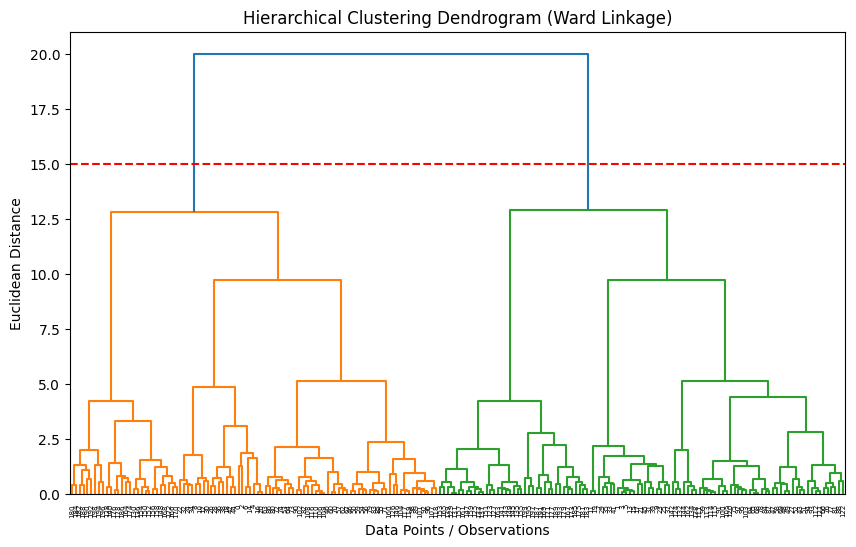

Agglomerative clustering successfully fitted.


In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Data Points / Observations')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

hc = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
print("Agglomerative clustering successfully fitted.")

## 5. Density-Based Spatial Clustering (DBSCAN)
Unlike K-Means and Hierarchical models, DBSCAN does not require pre-specifying $k$ and is highly effective at identifying arbitrary shapes and isolating noise (outliers). We tune the epsilon (`eps`) radius parameter by plotting the $k$-distance graph, looking for the point of maximum curvature.


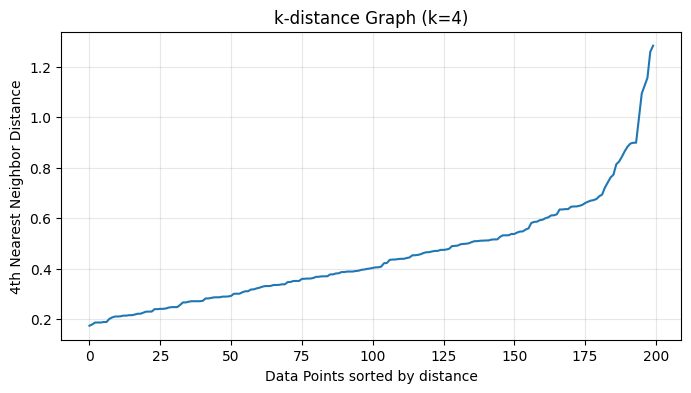

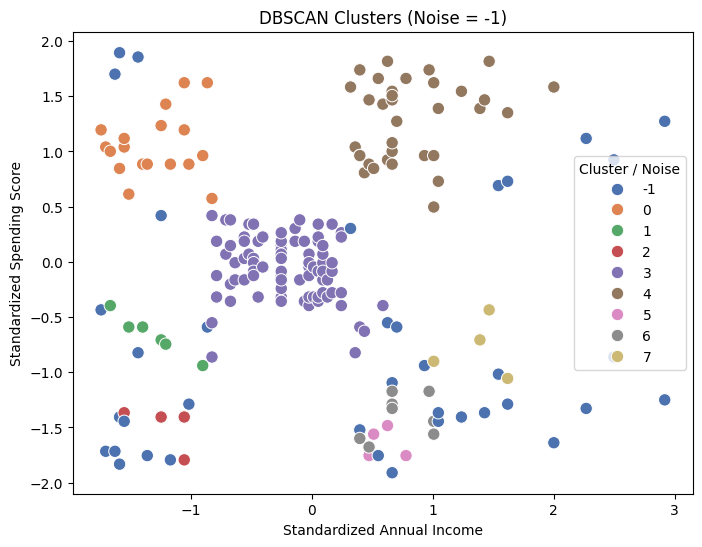

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# k-distance graph for tuning eps
min_samples = 4 # Rule of thumb: D + 1, where D is dimensionality
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title(f'k-distance Graph (k={min_samples})')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True, alpha=0.3)
plt.show()

chosen_eps = 0.5
dbscan = DBSCAN(eps=chosen_eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:, 1], y=X_scaled[:, 2], hue=db_labels, palette='deep', s=80)
plt.title('DBSCAN Clusters (Noise = -1)')
plt.xlabel('Standardized Annual Income')
plt.ylabel('Standardized Spending Score')
plt.legend(title='Cluster / Noise')
plt.show()

## 6. Algorithm Comparison Matrix

| Feature | K-Means | Agglomerative (Hierarchical) | DBSCAN |
| :--- | :--- | :--- | :--- |
| **Assumptions** | Spherical, equally sized clusters | Hierarchical dataset structure | Clusters are dense regions separated by sparse areas |
| **Handling of Outliers/Noise** | Poor (Forces outliers into nearest cluster, shifting centroids) | Moderate (Outliers can form their own sub-branches) | Excellent (Explicitly isolates noise as label `-1`) |
| **Pre-specify number of clusters?** | Yes (Requires `n_clusters`) | Yes (To truncate dendrogram) | No (Discovers clusters dynamically) |
| **Scalability** | High ($O(n)$ complexity, very fast) | Low ($O(n^3)$ complexity, memory heavy) | Moderate ($O(n \log n)$ with spatial indexing) |

## 7. Clustering Summary

Through the application of K-Means and Hierarchical clustering methodologies, five distinct, meaningful customer segments were successfully identified within the multi-dimensional feature space (Age, Income, Spending Score).

Among the evaluated models, K-Means produced the most interpretable and actionable clusters, largely due to the inherently spherical and cleanly partitioned variance of the dataset's income-to-spending ratio. DBSCAN, while excellent at isolating sparse data points (noise), fragmented the boundary regions excessively due to the lack of dense, non-linear cluster shapes.

In business terms, these segments can be mapped as follows:
1. **Careful Customers:** High Income / Low Spending (Conservative)
2. **Target Customers (High-Value):** High Income / High Spending (Brand loyalists)
3. **Standard Customers:** Average Income / Average Spending (Mass market)
4. **Careless Customers:** Low Income / High Spending (Impulsive buyers)
5. **Sensible Customers:** Low Income / Low Spending (Frugal/Necessity buyers)

**Hypothesis regarding the High-Value Segment:**
The core driver of the "Target Customer" segment (High Income / High Spending) is likely localized experiential retail rather than standard goods acquisition. Because their disposable income is high, their spending behavior is likely driven by premium brand clustering, personalized clienteling, and luxury mall amenities. Engaging this segment requires loyalty programs tied to exclusive early access events or VIP concierge services, which leverage their high spending ceiling.